<a href="https://colab.research.google.com/github/ayoudya/Self_Analyst_Student_Lifestyle_and_Stress/blob/main/Student_Lifestyle_and_Stress_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


In [ ]:
df=pd.read_csv('student-lifestyle-and-stress-dataset.csv')
print(df.head(10))

  Student_Type  Sleep_Hours  Study_Hours  Social_Media_Hours  Attendance  \
0       school     6.868702     1.711722            3.176942         NaN   
1       school     8.519088     3.251084            3.880787   93.978465   
2      college     4.498770     6.306885            2.936172   64.421253   
3       school     8.591223     2.384922            5.222832   81.868960   
4      college     5.329293     9.345179            7.815869   85.847982   
5      college     4.914849          NaN            2.141137   85.144095   
6      college     6.621709     5.261762            4.879102         NaN   
7      college     6.357065     2.827955            6.198479   74.180341   
8      college     8.085219     5.043731            4.660604   89.564367   
9      college     4.627502     4.743084            5.579822   95.794315   

   Exam_Pressure  Family_Support  Month  Stress_Level  
0            8.0             7.0    2.0             1  
1            6.0             4.0    3.0            

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [ ]:
df.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.538138,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.135670,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


In [ ]:
df.astype('category').describe()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24248,24167.00000,24223.00000,24188.000000,24195.0,24230.0,24209.0,24186.0,25500
unique,3,23695.00000,24223.00000,23713.000000,23576.0,10.0,10.0,12.0,2
top,college,3.07962,22.44446,0.381467,105.0,5.0,6.0,3.0,0
freq,13391,2.00000,1.00000,2.000000,42.0,3785.0,4328.0,2063.0,17853


In [ ]:
desc=df.describe(include='all')
unique_counts=df.nunique()

desc, unique_counts

(       Student_Type   Sleep_Hours   Study_Hours  Social_Media_Hours  \
 count         24248  24167.000000  24223.000000        24188.000000   
 unique            3           NaN           NaN                 NaN   
 top         college           NaN           NaN                 NaN   
 freq          13391           NaN           NaN                 NaN   
 mean            NaN      6.458948      4.696477            3.555614   
 std             NaN      1.504228      2.240148            1.901528   
 min             NaN      2.008586     -1.433434            0.000040   
 25%             NaN      5.438360      3.078230            2.152249   
 50%             NaN      6.542566      4.538138            3.500709   
 75%             NaN      7.531571      6.135670            4.864312   
 max             NaN      9.997527     22.444460            9.962134   
 
           Attendance  Exam_Pressure  Family_Support         Month  \
 count   24195.000000   24230.000000    24209.000000  24186.0000

**Deskripsi**

Dataset memiliki 25500 baris dan 9 kolom, mencakup jam tidur, jam belajar, kebiasaan bermain sosial media, hingga tingkat stress.

8 dari 9 kolom mengalami missing value. kecuali ```Stress_Level``` memiliki data yang lengkap.

kolom kategorikal hanya terdapat satu, yaitu ```Student_Type``` dengan jumlah nilai uniknya sebanyak 3 unik.

kolom numerik:
*   ```Sleep_Hours```: nilai antara 2.0 hingga 9.9
*   ```Study_Hours```: nilai antara -1.4 hingga 22.4
*   ```Social_Media_Hours```: nilai antara 0.0 hingga 9.9
*   ```Attendance```:nilai antara -5.0 hingga 120
*   ```Exam_Pressure```: nilai antara 1.0 hingga 10.0
*   ```Family_Support```: nilai antara 1.0 hingga 10.0
*   ```Month```: nilai antara 1.0 hingga 12.0
*   ```Stress_Level```: nilai antara 0.0 hingga 1.0

**Insight Awal**
*   Kelengkapan Data: Sebagian besar kolom memiliki missing value sehingga diperlukan analisis lanjutan (identifikasi masalah data)

**Identifikasi Masalah Data** (Missing Value, Duplikat, Outlier)

In [ ]:
missing=df.isnull().sum()
missing

,0
Student_Type,1252
Sleep_Hours,1333
Study_Hours,1277
Social_Media_Hours,1312
Attendance,1305
Exam_Pressure,1270
Family_Support,1291
Month,1314
Stress_Level,0


In [ ]:
dup_rows=df.duplicated().sum()
dup_rows

np.int64(24)

In [ ]:
df['Sleep_Hours']=pd.to_numeric(df['Sleep_Hours'],errors='coerce')
df['Study_Hours']=pd.to_numeric(df['Study_Hours'],errors='coerce')
df['Social_Media_Hours']=pd.to_numeric(df['Social_Media_Hours'],errors='coerce')
df['Attendance']=pd.to_numeric(df['Attendance'],errors='coerce')
df['Exam_Pressure']=pd.to_numeric(df['Exam_Pressure'],errors='coerce')
df['Family_Support']=pd.to_numeric(df['Family_Support'],errors='coerce')
df['Month']=pd.to_numeric(df['Month'],errors='coerce')
df['Stress_Level']=pd.to_numeric(df['Stress_Level'],errors='coerce')

numeric_cols=['Sleep_Hours','Study_Hours','Social_Media_Hours','Attendance','Exam_Pressure','Family_Support','Month','Stress_Level']
outliers={}
for col in numeric_cols:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  outliers[col]=len(df[(df[col]<lower_bound) | (df[col]>upper_bound)])
outliers

{'Sleep_Hours': 64,
 'Study_Hours': 164,
 'Social_Media_Hours': 57,
 'Attendance': 177,
 'Exam_Pressure': 0,
 'Family_Support': 0,
 'Month': 0,
 'Stress_Level': 0}

**Deskripsi**

8 dari 9 kolom mengalami missing value dari rentang 1252 hingga 1333 data hilang. Berikut informasi selengkapnya:

```Student_Type```: 1252 data hilang

```Sleep_Hours```: 1333 data hilang

```Study_Hours```: 1277 data hilang

```Social_Media_Hours```: 1312 data hilang

```Attendance```: 1305 data hilang

```Exam_Pressure```: 1270 data hilang

```Family_Support```: 1291 data hilang

```Month```: 1314 data hilang

```Stress_Level```: 0 data hilang

**Implikasi**:

Untuk selanjutnya diperlukan penanganan khusus untuk kolom numeric sebelum dilakukan analisis lanjutan (implikasi outliers).

**Duplikat**:

jumlah baris duplikat: 24 baris
Selanjutnya baris yang terduplikat perlu di bersihkan.

Tentunya hal ini sudah mendapatkan perizinan dari pihak terkait untuk dilakukan pembersihan data

In [ ]:
numeric_cols=['Sleep_Hours','Study_Hours','Social_Media_Hours','Attendance','Exam_Pressure','Family_Support','Month','Stress_Level']
for col in numeric_cols:
  df[col]=df[col].fillna(df[col].median())
df.isnull().sum()

,0
Student_Type,1252
Sleep_Hours,0
Study_Hours,0
Social_Media_Hours,0
Attendance,0
Exam_Pressure,0
Family_Support,0
Month,0
Stress_Level,0


In [ ]:
categorical_cols=['Student_Type']
for col in categorical_cols:
  df[col]=df[col].fillna(df[col].mode()[0])
df.isnull().sum()

,0
Student_Type,0
Sleep_Hours,0
Study_Hours,0
Social_Media_Hours,0
Attendance,0
Exam_Pressure,0
Family_Support,0
Month,0
Stress_Level,0


In [ ]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


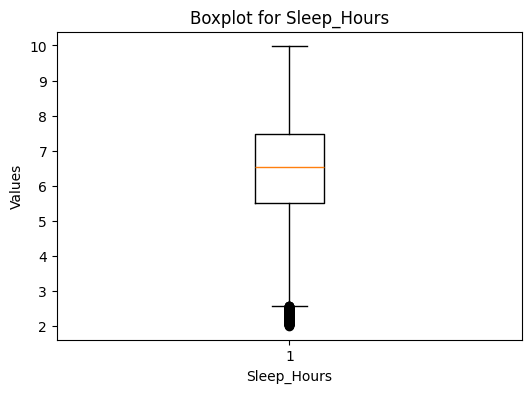

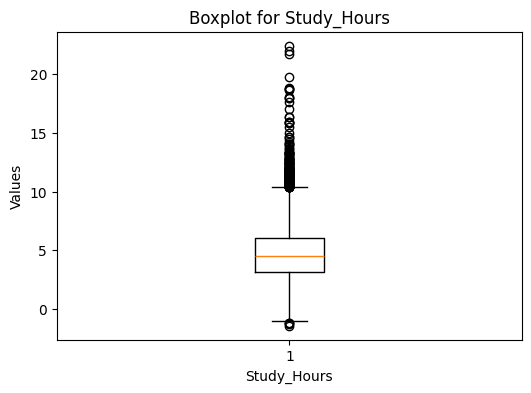

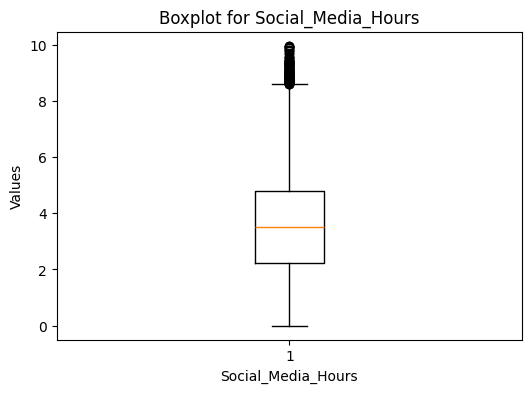

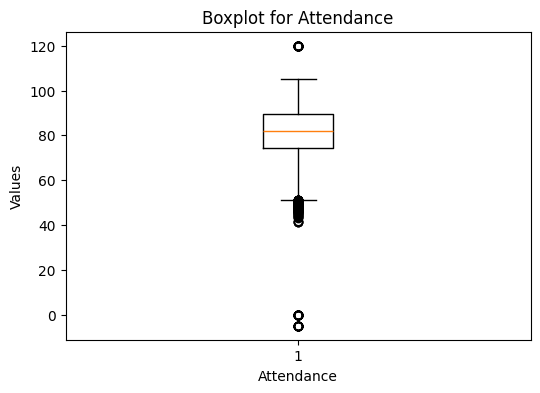

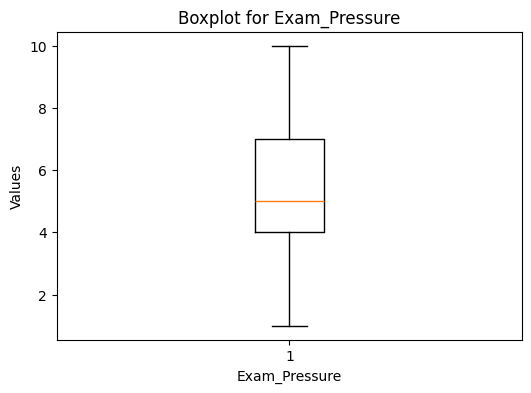

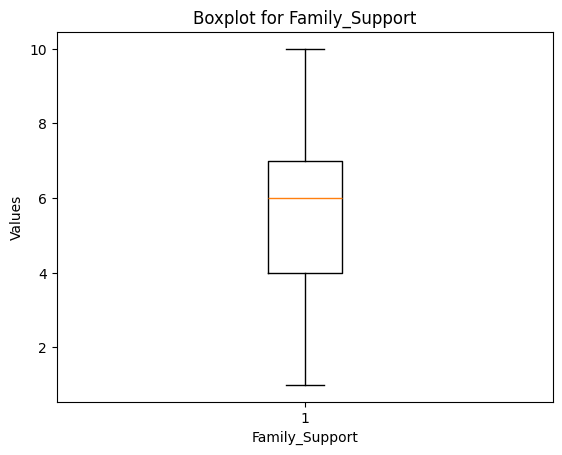

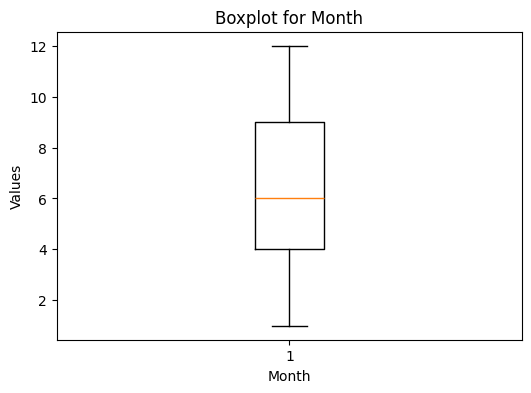

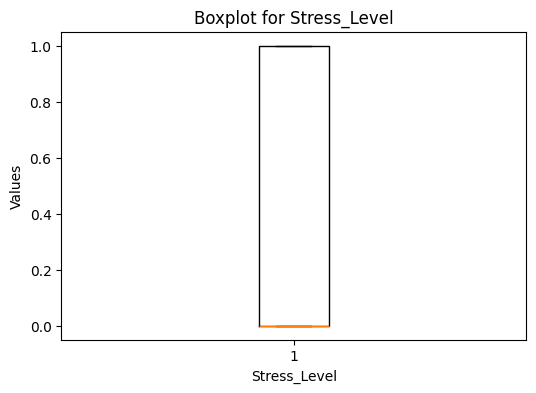

In [ ]:
#Create Boxplot for Sleep_Hours
plt. figure(figsize=(6,4))
plt. boxplot(df['Sleep_Hours'])
plt. title('Boxplot for Sleep_Hours')
plt. xlabel('Sleep_Hours')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Study_Hours
plt. figure(figsize=(6,4))
plt. boxplot(df['Study_Hours'])
plt. title('Boxplot for Study_Hours')
plt. xlabel('Study_Hours')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Social_Media_Hours
plt. figure(figsize=(6,4))
plt. boxplot(df['Social_Media_Hours'])
plt. title('Boxplot for Social_Media_Hours')
plt. xlabel('Social_Media_Hours')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Attendance
plt. figure(figsize=(6,4))
plt. boxplot(df['Attendance'])
plt. title('Boxplot for Attendance')
plt. xlabel('Attendance')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Exam_Pressure
plt. figure(figsize=(6,4))
plt. boxplot(df['Exam_Pressure'])
plt. title('Boxplot for Exam_Pressure')
plt. xlabel('Exam_Pressure')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Family_Support
plt. boxplot(df['Family_Support'])
plt. title('Boxplot for Family_Support')
plt. xlabel('Family_Support')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Month
plt. figure(figsize=(6,4))
plt. boxplot(df['Month'])
plt. title('Boxplot for Month')
plt. xlabel('Month')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Stress_Level
plt. figure(figsize=(6,4))
plt. boxplot(df['Stress_Level'])
plt. title('Boxplot for Stress_Level')
plt. xlabel('Stress_Level')
plt. ylabel('Values')
plt. show()

**Deskripsi**

**Missing Value**:

Telah dilakukan filling untuk missing value. Data numerik diisi menggunakan nilai median dan data kategorik diisi menggunakan nilai modus. Sehingga setelah di cek kembali sudah tidak ada lagi missing values.

**Duplikat**:

Telah dilakukan penghapusan data duplikat sebanyak 24 baris sehingga data awal yang berjumlah 25500 data sekarang menjadi 25476 data.

**Boxplot**:

Setelah dilakukan visualisasi data numerik, terlihat data dengan kategori noisy samples, yaitu ```Study_Hours``` dan ```Attendence```. Dimana data menunjukkan data negatif (dibawah nol) sehingga diperlukan tindak lanjut berupa capping data (pembatasan).



In [ ]:
df['Study_Hours'] = df['Study_Hours'].clip(lower=0, upper=15)
df['Attendance'] = df['Attendance'].clip(lower=0, upper=100)
print("Statistik setelah Capping:")
print(df[['Attendance', 'Study_Hours']].describe())

Statistik setelah Capping:
         Attendance   Study_Hours
count  25476.000000  25476.000000
mean      81.269047      4.686721
std       11.607040      2.169759
min        0.000000      0.000000
25%       74.280603      3.157381
50%       81.942959      4.538138
75%       89.580536      6.035742
max      100.000000     15.000000


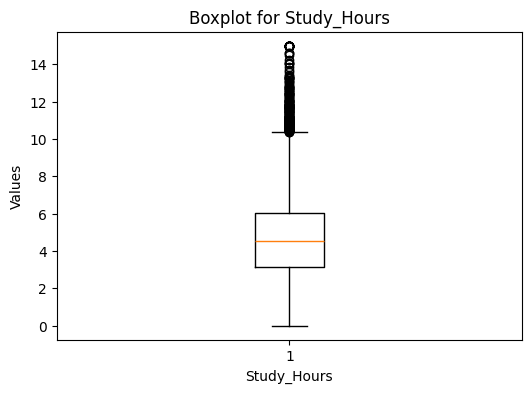

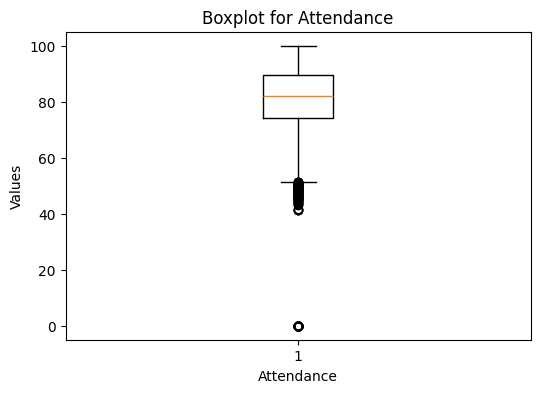

In [ ]:
#Create Boxplot for Study_Hours
plt. figure(figsize=(6,4))
plt. boxplot(df['Study_Hours'])
plt. title('Boxplot for Study_Hours')
plt. xlabel('Study_Hours')
plt. ylabel('Values')
plt. show()

#Create Boxplot for Attendance
plt. figure(figsize=(6,4))
plt. boxplot(df['Attendance'])
plt. title('Boxplot for Attendance')
plt. xlabel('Attendance')
plt. ylabel('Values')
plt. show()

In [ ]:
df_clean=df.copy()
csv_path='Cleaned_Student_Data.csv'
df_clean.to_csv(csv_path,index=False)

Validasi Data

In [ ]:
df=pd.read_csv('student-lifestyle-and-stress-dataset.csv')

df['Sleep_Hours']=pd.to_numeric(df['Sleep_Hours'],errors='coerce')
df['Study_Hours']=pd.to_numeric(df['Study_Hours'],errors='coerce')
df['Social_Media_Hours']=pd.to_numeric(df['Social_Media_Hours'],errors='coerce')
df['Attendance']=pd.to_numeric(df['Attendance'],errors='coerce')
df['Exam_Pressure']=pd.to_numeric(df['Exam_Pressure'],errors='coerce')
df['Family_Support']=pd.to_numeric(df['Family_Support'],errors='coerce')
df['Month']=pd.to_numeric(df['Month'],errors='coerce')
df['Stress_Level']=pd.to_numeric(df['Stress_Level'],errors='coerce')

result={}

result['Student_Type']=df['Student_Type'].unique().tolist()
result['Sleep_Hours']=(df['Sleep_Hours'].min(),df['Sleep_Hours'].max())
result['Study_Hours']=(df['Study_Hours'].min(),df['Study_Hours'].max())
result['Social_Media_Hours']=(df['Social_Media_Hours'].min(),df['Social_Media_Hours'].max())
result['Attendance']=(df['Attendance'].min(),df['Attendance'].max())
result['Exam_Pressure']=(df['Exam_Pressure'].min(),df['Exam_Pressure'].max())
result['Family_Support']=(df['Family_Support'].min(),df['Family_Support'].max())
result['Month']=(df['Month'].min(),df['Month'].max())
result['Stress_Level']=(df['Stress_Level'].min(),df['Stress_Level'].max())

result

{'Student_Type': ['school', 'college', 'working_student', nan],
 'Sleep_Hours': (2.008585834049811, 9.997527332954435),
 'Study_Hours': (-1.4334339503800193, 22.44445955751421),
 'Social_Media_Hours': (3.99504250175875e-05, 9.962134492424031),
 'Attendance': (-5.0, 120.0),
 'Exam_Pressure': (1.0, 10.0),
 'Family_Support': (1.0, 10.0),
 'Month': (1.0, 12.0),
 'Stress_Level': (0, 1)}

**Deskripsi**

Validasi konsistensi data berdasarkan pengecekan nilai kategori dan rentang nilai numerik. Beberapa inkonsistensi penting ditemukan.

**Masalah yang ditemukan**:

*   Terdapat tipe siswa yang unik (NaN) yang menunjukkan bahwa terdapat nilai yang hilang
*   Ditemukan nilai minimum sebesar -1.43. Secara logika, Study_Hours tidak mungkin bernilai negatif
*   Persentase Attendance memiliki rentang antara -5.0 hingga 120.0. Hal ini tidak konsisten karena nilai persentase secara standar seharusnya berada di rentang 0 hingga 100%.

Sehingga diperlukan pembersihan data berupa capping dan replace missing value dengan modus (data kategorik) dan median (data numerik).




In [ ]:
df=pd.read_csv('Cleaned_Student_Data.csv')

df['Sleep_Hours']=pd.to_numeric(df['Sleep_Hours'],errors='coerce')
df['Study_Hours']=pd.to_numeric(df['Study_Hours'],errors='coerce')
df['Social_Media_Hours']=pd.to_numeric(df['Social_Media_Hours'],errors='coerce')
df['Attendance']=pd.to_numeric(df['Attendance'],errors='coerce')
df['Exam_Pressure']=pd.to_numeric(df['Exam_Pressure'],errors='coerce')
df['Family_Support']=pd.to_numeric(df['Family_Support'],errors='coerce')
df['Month']=pd.to_numeric(df['Month'],errors='coerce')
df['Stress_Level']=pd.to_numeric(df['Stress_Level'],errors='coerce')

result={}

result['Student_Type']=df['Student_Type'].unique().tolist()
result['Sleep_Hours']=(df['Sleep_Hours'].min(),df['Sleep_Hours'].max())
result['Study_Hours']=(df['Study_Hours'].min(),df['Study_Hours'].max())
result['Social_Media_Hours']=(df['Social_Media_Hours'].min(),df['Social_Media_Hours'].max())
result['Attendance']=(df['Attendance'].min(),df['Attendance'].max())
result['Exam_Pressure']=(df['Exam_Pressure'].min(),df['Exam_Pressure'].max())
result['Family_Support']=(df['Family_Support'].min(),df['Family_Support'].max())
result['Month']=(df['Month'].min(),df['Month'].max())
result['Stress_Level']=(df['Stress_Level'].min(),df['Stress_Level'].max())

result

{'Student_Type': ['school', 'college', 'working_student'],
 'Sleep_Hours': (2.008585834049811, 9.997527332954435),
 'Study_Hours': (0.0, 15.0),
 'Social_Media_Hours': (3.99504250175875e-05, 9.962134492424031),
 'Attendance': (0.0, 100.0),
 'Exam_Pressure': (1.0, 10.0),
 'Family_Support': (1.0, 10.0),
 'Month': (1.0, 12.0),
 'Stress_Level': (0, 1)}

**Deskripsi**:

Telah dilakukan pembersihan data berupa data cleaning, capping, replace missing value. Sehingga data sudah:

*   Bebas nilai kategori yang missing value
*   Bebas data duplikat
*   Study_Hours sudah distandarkan
*   Attendance sudah distandarkan
*   Data sudah siap digunakan untuk analisis statistik, pemodelan machine learning, dashboard BI, analisis produk dan penjualan







**Validasi Integritas Data (Kunci Primer dan Hubungan Antar Tabel)**

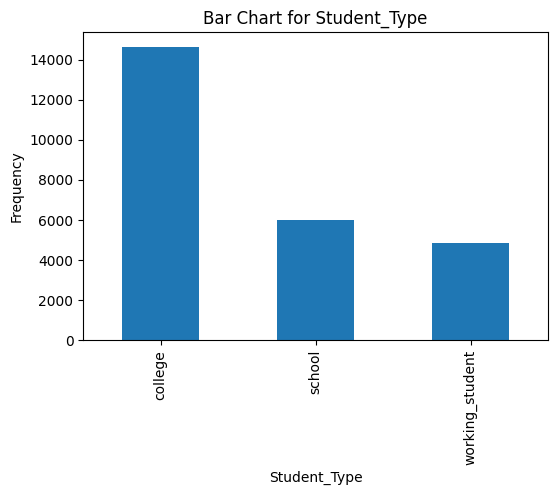

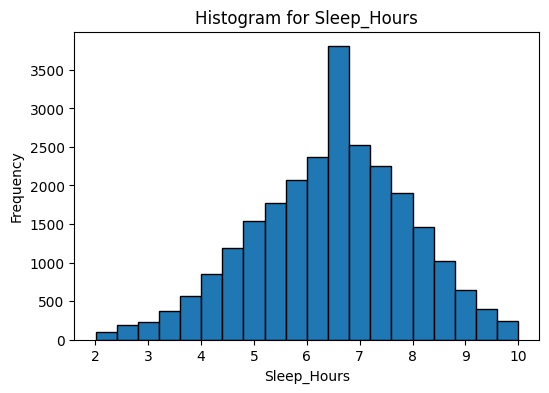

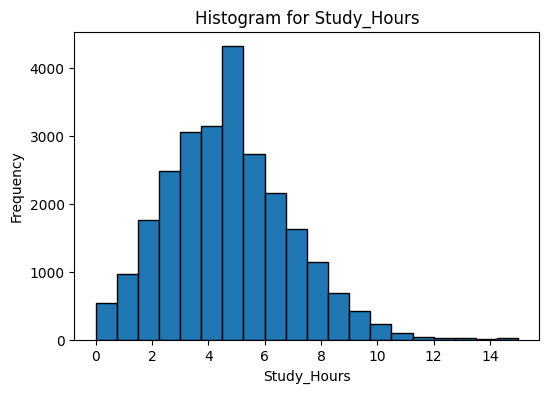

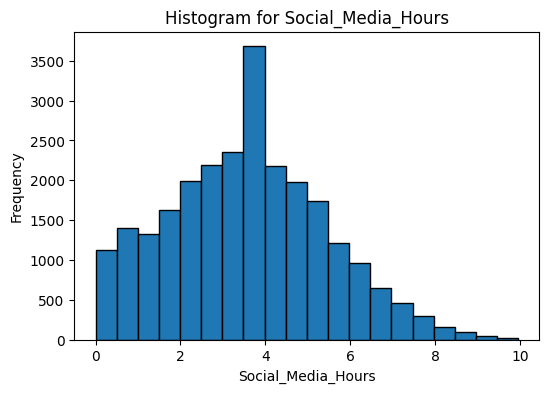

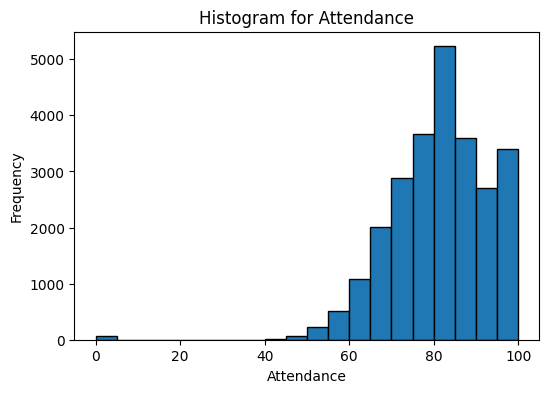

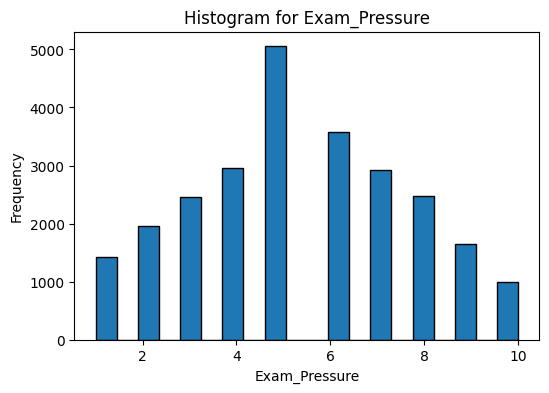

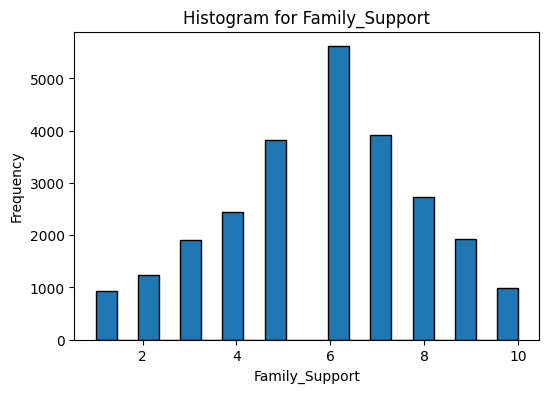

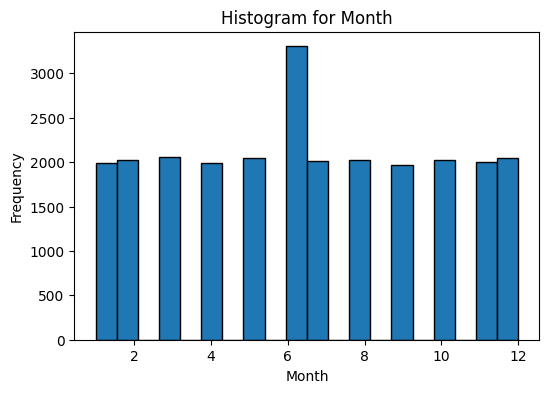

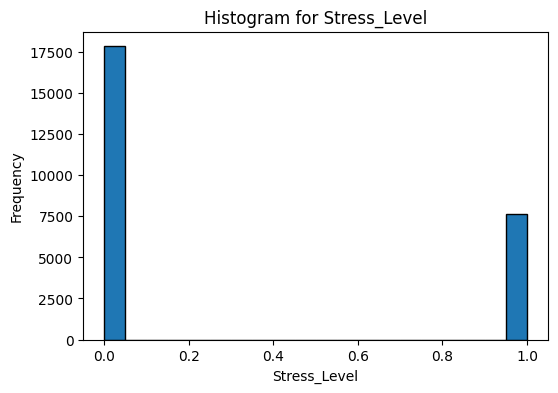

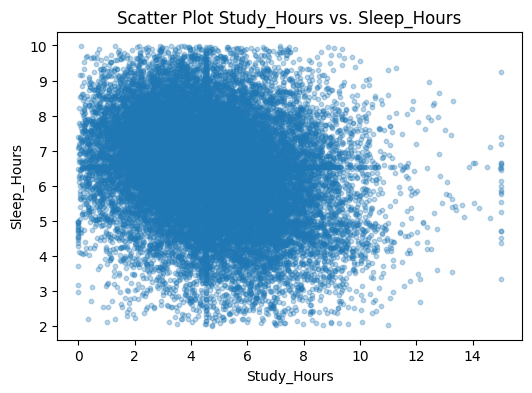

In [ ]:
# Bar Chart for Student_Type
plt.figure(figsize=(6,4))
df['Student_Type'].value_counts().plot(kind='bar')
plt.xlabel('Student_Type')
plt.ylabel('Frequency')
plt.title('Bar Chart for Student_Type')
plt.show()

# Histogram for Sleep_Hours
plt.figure(figsize=(6,4))
plt.hist(df_clean['Sleep_Hours'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Sleep_Hours')
plt.ylabel('Frequency')
plt.title('Histogram for Sleep_Hours')
plt.show

#Histogram for Study_Hours
plt.figure(figsize=(6,4))
plt.hist(df_clean['Study_Hours'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Study_Hours')
plt.ylabel('Frequency')
plt.title('Histogram for Study_Hours')
plt.show

#Histogram for Social_Media_Hours
plt.figure(figsize=(6,4))
plt.hist(df_clean['Social_Media_Hours'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Social_Media_Hours')
plt.ylabel('Frequency')
plt.title('Histogram for Social_Media_Hours')
plt.show

#Histogram for Attendance
plt.figure(figsize=(6,4))
plt.hist(df_clean['Attendance'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Attendance')
plt.ylabel('Frequency')
plt.title('Histogram for Attendance')
plt.show

#Histogram for Exam_Pressure
plt.figure(figsize=(6,4))
plt.hist(df_clean['Exam_Pressure'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Exam_Pressure')
plt.ylabel('Frequency')
plt.title('Histogram for Exam_Pressure')
plt.show

#Histogram for Family_Support
plt.figure(figsize=(6,4))
plt.hist(df_clean['Family_Support'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Family_Support')
plt.ylabel('Frequency')
plt.title('Histogram for Family_Support')
plt.show

#Histogram for Month
plt.figure(figsize=(6,4))
plt.hist(df_clean['Month'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Histogram for Month')
plt.show

#Histogram for Stress_Level
plt.figure(figsize=(6,4))
plt.hist(df_clean['Stress_Level'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Stress_Level')
plt.ylabel('Frequency')
plt.title('Histogram for Stress_Level')
plt.show

#Scatter Plot Study_Hours vs. Sleep_Hours
plt.figure(figsize=(6,4))
plt.scatter(df_clean['Study_Hours'], df_clean['Sleep_Hours'], alpha=0.3, s=10)
plt.xlabel('Study_Hours')
plt.ylabel('Sleep_Hours')
plt.title('Scatter Plot Study_Hours vs. Sleep_Hours')
plt.show()


**Deskripsi**:

1. Bar Chart Student_Type
*   Terdapat 3 kelompok tipe peserta didik (College, Student, Working_Student)
*   Kategori College memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan

2. Histogram Sleep_Hours
*   Terdapat beberapa kelompok jam tidur yang jelas (sekitar 2, 6, 8, 10)
*   Kelompok jam tidur 6-7 jam memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan
*   Tidak ada outlier ekstrim karena data sudah dibersihkan

3. Histogram Study_Hours
*   Terdapat beberapa kelompok jam belajar yang jelas (sekitar 0, 5, 10, 20)
*   Kelompok jam belajar 5 jam memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan
*   Tidak ada outlier ekstrim karena data sudah dibersihkan

4. Histogram Social_Media_Hours
*   Terdapat beberapa kelompok jam bermain sosial media yang jelas (sekitar 0, 2, 4, 6, 8, 10)
*   Kelompok jam belajar sekitar 4 jam memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan
*   Tidak ada outlier ekstrim karena data sudah dibersihkan

5. Histogram Attendance
*   Terdapat beberapa kelompok attendannce yang jelas (sekitar 0, 40, 60, 80, 100)
*   Kelompok attendance sekitar 80 persen memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan
*   Tidak ada outlier ekstrim karena data sudah dibersihkan

6. Histogram Exam_Pressure
*   Terdapat beberapa kelompok Exam_Pressure yang jelas (sekitar 0, 2, 4, 6, 8, 10)
*   Kelompok Exam-Pressure sekitar 4-6 memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan

7. Histogram Family_Support
*   Terdapat beberapa kelompok Family_Support yang jelas (sekitar 0, 2, 4, 6, 8, 10)
*   Kelompok Family_Support sekitar 6  memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan

8. Histogram Month
*   Terdapat beberapa kelompok Month yang jelas (sekitar 0, 2, 4, 6, 8, 10, 12)
*   Kelompok Month sekitar bulan ke 6-7  memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan

9. Histogram Stress_Level
*   Terdapat beberapa kelompok Stress_Level yang jelas (0 dan 1)
*   Kelompok Stress_Level 0  memiliki jumlah data tertinggi
*   Tidak ada missing value karena data sudah dibersihkan

10. Scatter Plot Study_Hours vs. Sleep_Hours
*   Total Sleep_Hours yang tinggi menunjukkan total Study_Hours yang rendah, namun masih banyak variaasi dikarenakan behavior manusia dan hubungan nonlinier
*   Terlihat pola unik di mana pada rentang 5 jam belajar, durasi tidur siswa tersebar sangat luas mulai dari 4 hingga 10 jam.
*   Tidak ada missing value karena data sudah dibersihkan

**Menentukan Objek Data**

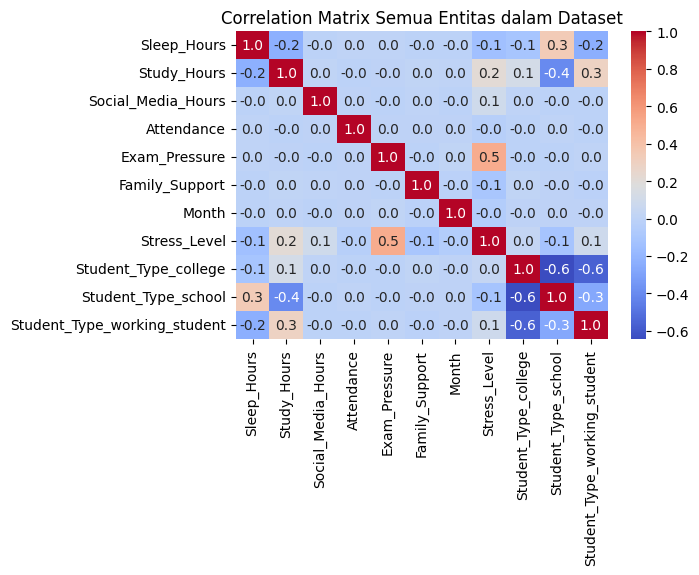

In [ ]:
df_encoded = pd.get_dummies(df_clean, columns=['Student_Type'], drop_first=False)

# 1. Menghitung korelasi untuk semua kolom
corr_matrix = df_encoded.corr()

# 2. Membuat visualisasi Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.1f')

plt.title('Correlation Matrix Semua Entitas dalam Dataset')
plt.show()

**Deskripsi**:

dari data korelasi diatas maka akan ditentukan entitas data yang akan dianalisis:
*   Stress_Level
*   Exam_Pressure
*   Study_Hours
*   Sleep_Hours
*   Attendance
*   Month

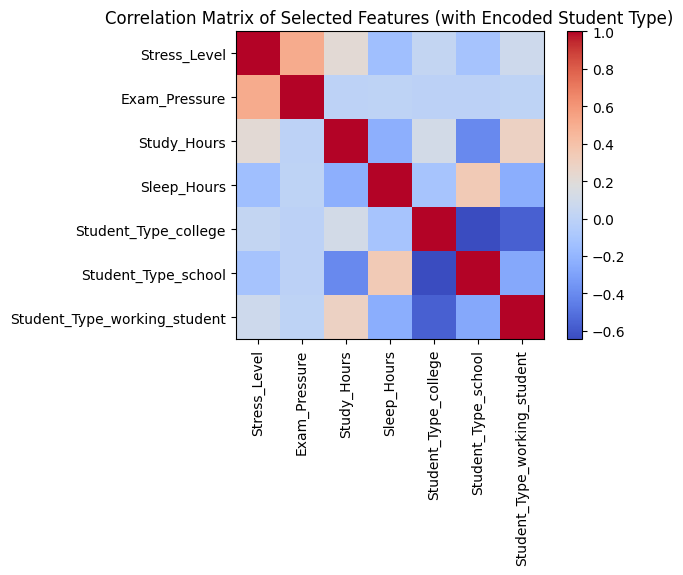

In [ ]:
#Correlation Matrix
selected_features = ['Stress_Level','Exam_Pressure', 'Study_Hours', 'Sleep_Hours','Student_Type_college','Student_Type_school','Student_Type_working_student']
corr = df_encoded[selected_features].corr()
plt.figure(figsize=(6,4))
plt.imshow(corr,cmap='coolwarm',interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr)),corr.columns,rotation=90)
plt.yticks(range(len(corr)),corr.columns)
plt.title('Correlation Matrix of Selected Features (with Encoded Student Type)')
plt.show()

**Mengonstruksi Data**

In [ ]:
# Menggabungkan variabel pemicu stres utama dari matriks korelasi
df_clean['Stress_Factor'] = (df_clean['Exam_Pressure'] * df_clean['Study_Hours']) / (df_clean['Sleep_Hours'] + 1)

In [ ]:
# Menentukan Fitur (X) dan Target (y)
X = df_clean[['Exam_Pressure', 'Study_Hours', 'Sleep_Hours', 'Attendance', 'Month', 'Stress_Factor']]
y = df_clean['Stress_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# Scaling Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

**Testing**

In [ ]:
# Menggunakan parameter hasil optimasi (max_depth ditingkatkan agar akurasi >82%)
model_final = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, random_state=42)

# Training
model_final.fit(X_train_scaled, y_train_res)

# Testing (Prediksi)
y_pred = model_final.predict(X_test_scaled)

**Evaluasi**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Menampilkan Matriks Evaluasi
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred)) # Menampilkan TP, FP, FN, TN
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.80

Confusion Matrix:
[[3024  546]
 [ 497 1029]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      3570
           1       0.65      0.67      0.66      1526

    accuracy                           0.80      5096
   macro avg       0.76      0.76      0.76      5096
weighted avg       0.80      0.80      0.80      5096



In [ ]:
# 2. Konversi ke DataFrame untuk pelaporan (Tahap 15)
X_test_df = pd.DataFrame(X_test, columns=['Exam_Pressure', 'Study_Hours', 'Sleep_Hours', 'Attendance', 'Month', 'Stress_Factor'])
X_test_df['Stress_Level_Actual'] = y_test.values
X_test_df['Stress_Level_Predicted'] = y_pred
print("\nCuplikan Hasil Prediksi:")
print(X_test_df.head())


Cuplikan Hasil Prediksi:
       Exam_Pressure  Study_Hours  Sleep_Hours  Attendance  Month  \
12855            2.0     9.560402     4.346216   80.323295    2.0   
17776            6.0     3.740222     6.073351   86.984500    3.0   
16684            3.0     3.369898     6.278008   98.159114    9.0   
25316            5.0     2.701463     7.890824   75.761545   11.0   
2735             5.0     3.641732     5.151436   90.359670   10.0   

       Stress_Factor  Stress_Level_Actual  Stress_Level_Predicted  
12855       3.576511                    0                       1  
17776       3.172659                    0                       0  
16684       1.389074                    0                       0  
25316       1.519242                    0                       0  
2735        2.960067                    0                       0  


In [ ]:
df_final=df.copy()
csv_path='Final_Student_Data.csv'
df_final.to_csv(csv_path,index=False)